In [2]:
##Visualización de Datos

In [3]:
import pandas as pd

df_final = pd.read_csv("../Práctica 1/glp1_limpio.csv", parse_dates=['FECHA'])

In [4]:
print(df_final['ACTUAL_COST'].quantile([0.90, 0.95, 0.99]))
#para empezar a crear la primera grfica, quiero ver los percentiles de la columna ACTUAL_COST, para ver dónde están los valores atípicos que puedan afectar la visualización.

0.90     697.65025
0.95    1104.14880
0.99    3060.14880
Name: ACTUAL_COST, dtype: float64


In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-whitegrid')  # fondo blanco con líneas de guía sutiles, look más limpio

sustancias_orden = ['Semaglutide', 'Liraglutide', 'Dulaglutide', 'Exenatide', 'Lixisenatide', 'Tirzepatide']
paleta = plt.cm.tab10.colors
color_sustancia = dict(zip(sustancias_orden, paleta))

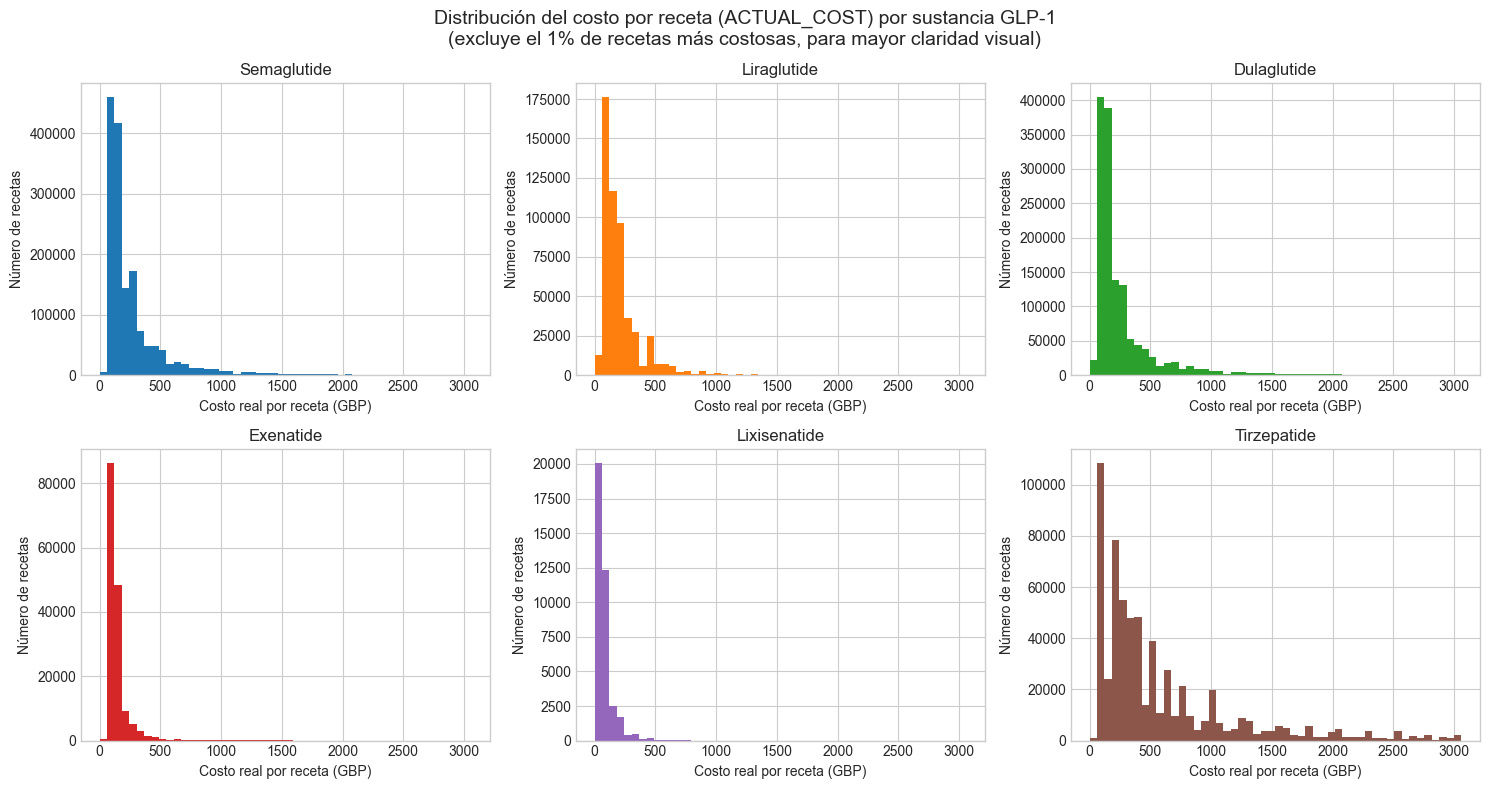

In [24]:
#se va a usar el percentil 99 como límite del eje x, para cortar la menor cantidad de datos  



limite = df_final['ACTUAL_COST'].quantile(0.99)
sustancias_lista = df_final['SUSTANCIA'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sustancia in enumerate(sustancias_lista):
    datos = df_final[df_final['SUSTANCIA'] == sustancia]['ACTUAL_COST']
    axes[i].hist(datos, bins=50, range=(0, limite), color=color_sustancia[sustancia])
    axes[i].set_title(sustancia)
    axes[i].set_xlabel('Costo real por receta (GBP)')
    axes[i].set_ylabel('Número de recetas')

fig.suptitle('Distribución del costo por receta (ACTUAL_COST) por sustancia GLP-1\n(excluye el 1% de recetas más costosas, para mayor claridad visual)', fontsize=14)
plt.tight_layout()
plt.show()


In [16]:
#Las 6 sustancias muestran distribuciones con sesgo a la derecha (muchas recetas baratas, pocas caras) — pero no todas de la misma forma. Semaglutide, Dulaglutide y Exenatide tienen casi todas sus recetas amontonadas en precios bajos, con una caída muy rápida hacia la derecha — son sustancias de precio consistente. Tirzepatide es la excepción clara: sus recetas están repartidas en todo el rango de precios, desde baratas hasta cerca de £3,000 — confirmado numéricamente con su desviación estándar (1,571, más de 4 veces la de cualquier otra). En resumen: no solo es la más cara en promedio, es la que tiene mayor variedad de precios entre sus propias recetas — probablemente por tener más presentaciones/dosis distintas conviviendo bajo la misma sustancia.

In [13]:
print(df_final.groupby('SUSTANCIA')['ACTUAL_COST'].std().sort_values(ascending=False))
#Tirzepatide no solo es más cara en promedio, es dramáticamente más variable en precio que cualquier otra sustancia del grupo.

SUSTANCIA
Tirzepatide     1571.380192
Dulaglutide      382.871694
Semaglutide      358.492171
Liraglutide      192.514227
Exenatide        133.102760
Lixisenatide      68.862034
Name: ACTUAL_COST, dtype: float64


In [14]:
#linea del tiempo para ver el revene mensual de cada sustancia durante el periodo de tiempo del dataset
revenue_mensual = df_final.groupby(['FECHA', 'SUSTANCIA'])['ACTUAL_COST'].sum()
revenue_mensual_tabla = revenue_mensual.unstack()
print(revenue_mensual_tabla.head())


SUSTANCIA    Dulaglutide     Exenatide   Liraglutide  Lixisenatide  \
FECHA                                                                
2021-01-01  4.515553e+06  556163.62817  3.704234e+06  157098.30944   
2021-02-01  4.352138e+06  526307.11083  3.466374e+06  140745.74509   
2021-03-01  4.987026e+06  574107.42166  3.794877e+06  152133.06248   
2021-04-01  4.995114e+06  527003.68862  3.668624e+06  146848.29551   
2021-05-01  4.916927e+06  502621.50133  3.436258e+06  138909.02529   

SUSTANCIA    Semaglutide  Tirzepatide  
FECHA                                  
2021-01-01  3.193905e+06          NaN  
2021-02-01  3.139435e+06          NaN  
2021-03-01  3.794719e+06          NaN  
2021-04-01  3.919205e+06          NaN  
2021-05-01  3.982829e+06          NaN  


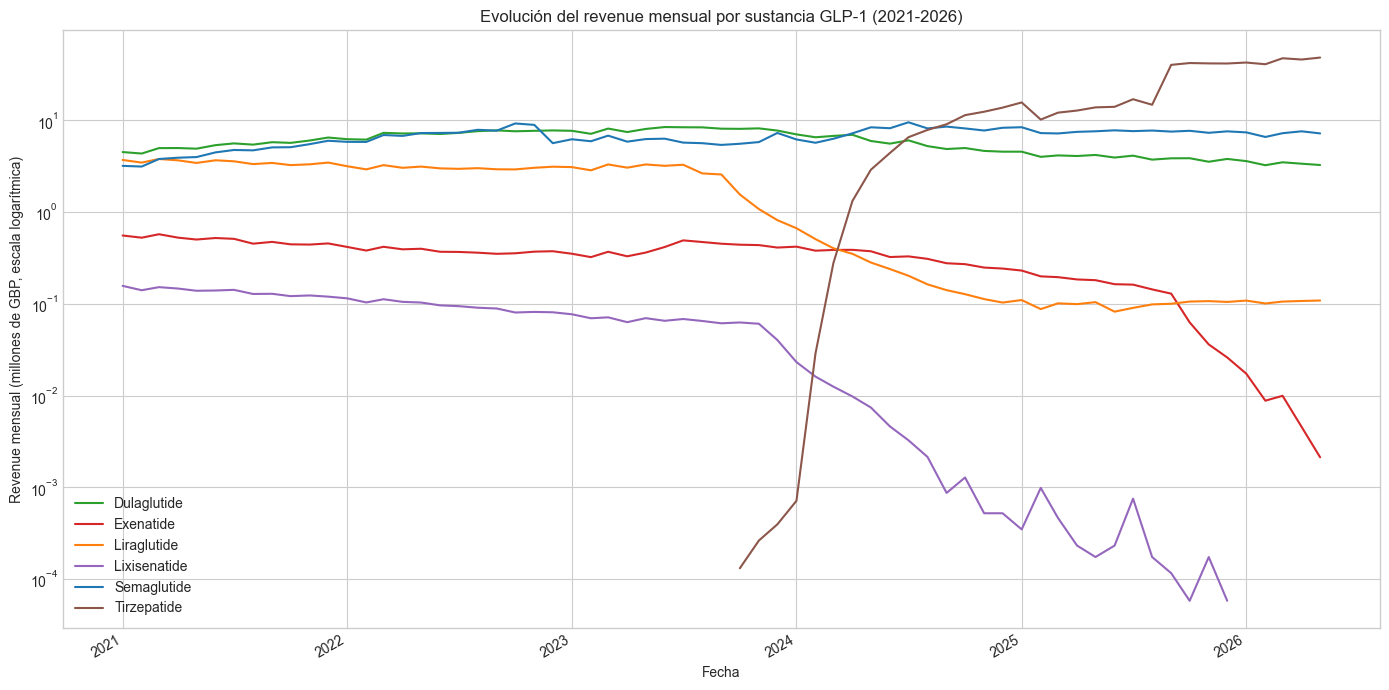

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))

for sustancia in revenue_mensual_tabla.columns:
    ax.plot(revenue_mensual_tabla.index, revenue_mensual_tabla[sustancia] / 1_000_000, 
            label=sustancia, color=color_sustancia[sustancia])

ax.set_yscale('log')
ax.set_xlabel('Fecha')
ax.set_ylabel('Revenue mensual (millones de GBP, escala logarítmica)')
ax.set_title('Evolución del revenue mensual por sustancia GLP-1 (2021-2026)')
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
##De 2021 a mediados de 2023, el mercado GLP-1 estaba dominado por 4 sustancias "clásicas" (Dulaglutide, Semaglutide, Liraglutide, Exenatide) moviéndose relativamente estables. A partir de ahí pasan 2 cosas al mismo tiempo: Liraglutide y Lixisenatide caen en picada (descontinuación real de fabricante) mientras Tirzepatide aparece de la nada y en menos de 2 años se convierte en la sustancia con más revenue de todas, superando incluso a Semaglutide y Dulaglutide

In [19]:
#Grafica de barras para ver quien es el que más revenue tiene en total, sumando todos los meses del periodo de tiempo del dataset
revenue_por_sustancia = df_final.groupby('SUSTANCIA')['ACTUAL_COST'].sum().sort_values(ascending=False) / 1_000_000
items_por_sustancia = df_final.groupby('SUSTANCIA')['ITEMS'].sum()
items_ordenado = items_por_sustancia[revenue_por_sustancia.index]

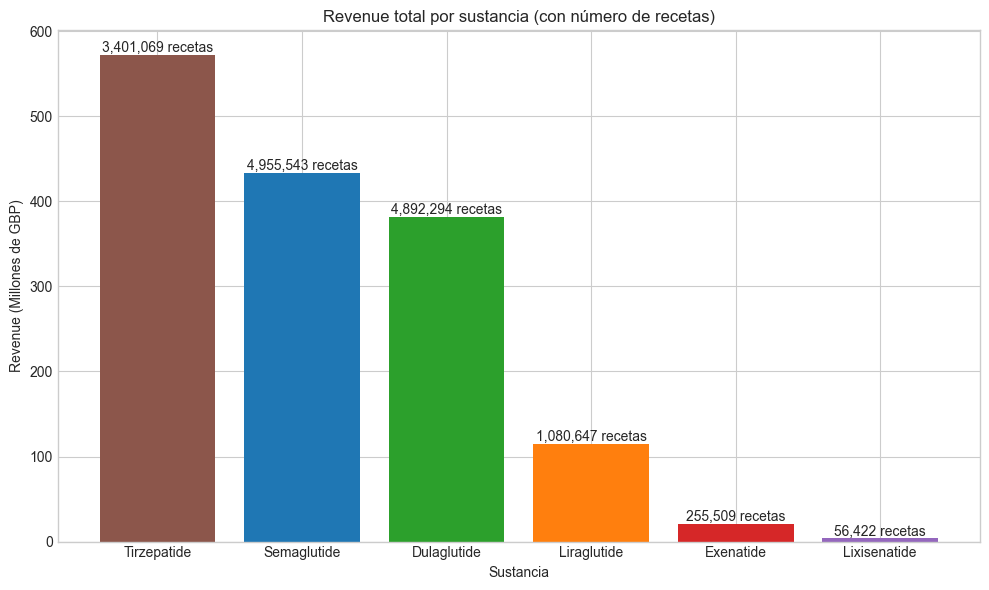

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
colores_barras = [color_sustancia[s] for s in revenue_por_sustancia.index]
barras = ax.bar(revenue_por_sustancia.index, revenue_por_sustancia.values, color=colores_barras)

for barra, items in zip(barras, items_ordenado):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura, f'{items:,} recetas', 
            ha='center', va='bottom')

ax.set_xlabel('Sustancia')
ax.set_ylabel('Revenue (Millones de GBP)')
ax.set_title('Revenue total por sustancia (con número de recetas)')

plt.tight_layout()
plt.show()

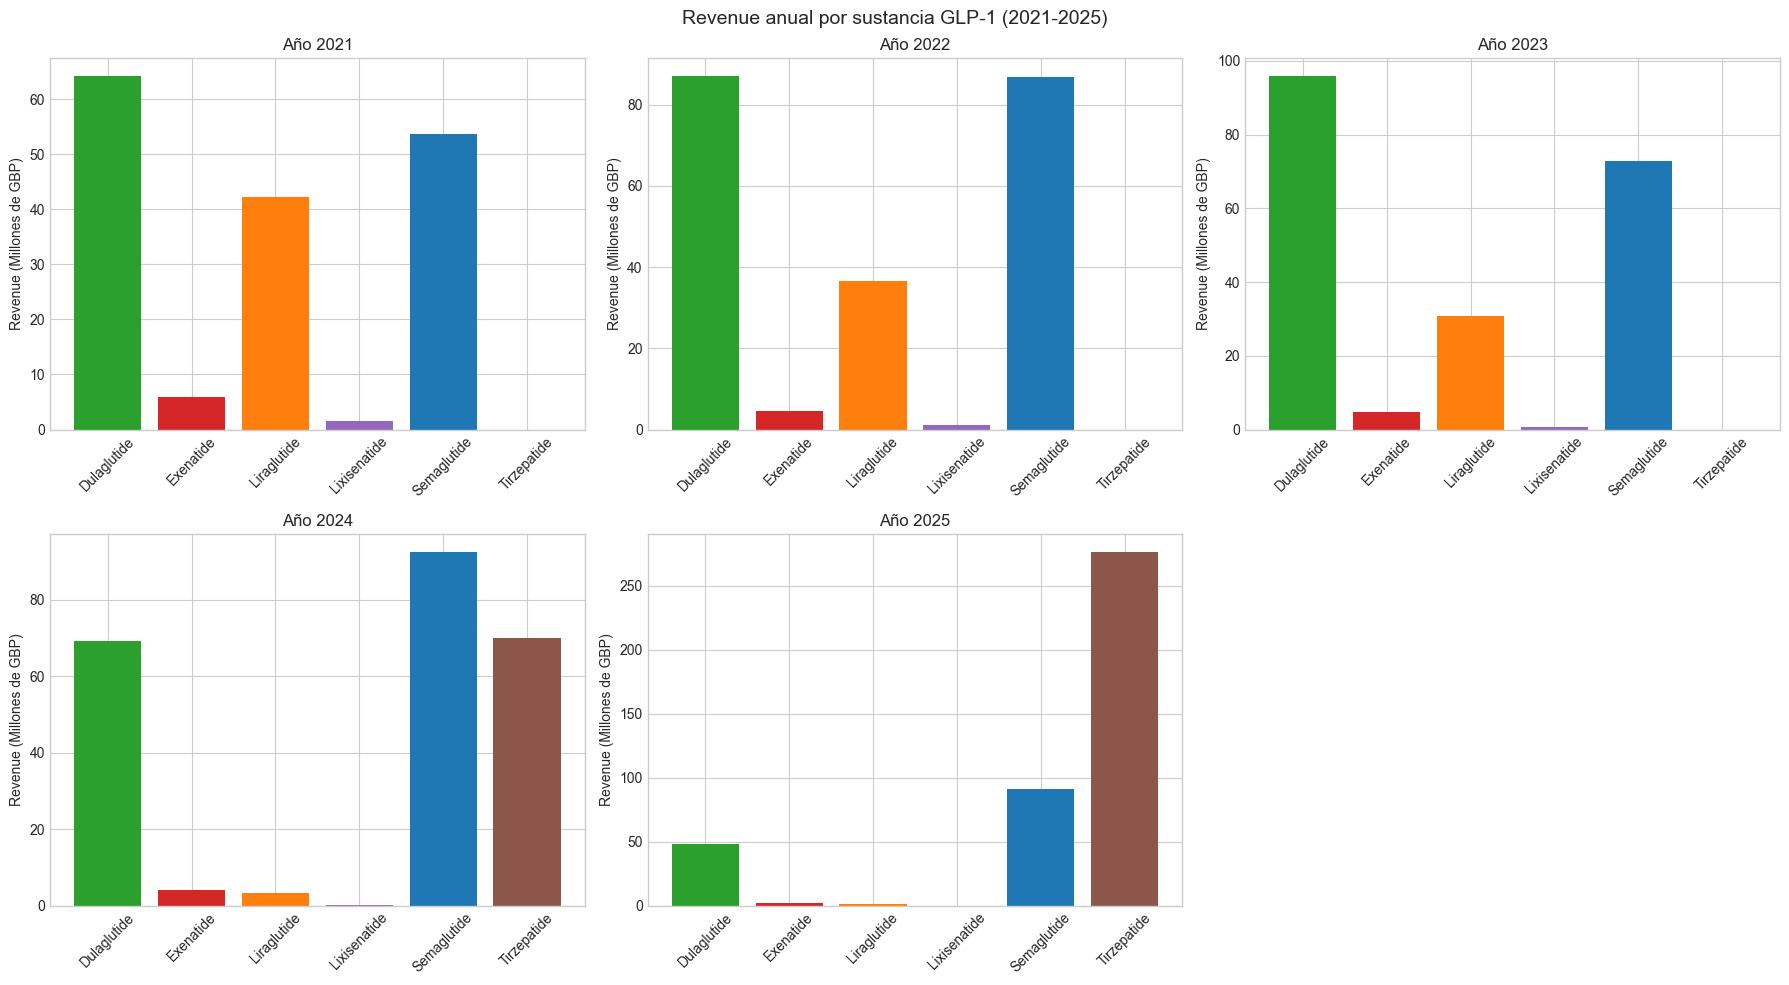

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, anio in enumerate(anios_completos):
    datos_anio = revenue_anio_sustancia.loc[anio] / 1_000_000
    colores = [color_sustancia[s] for s in datos_anio.index]
    axes[i].bar(datos_anio.index, datos_anio.values, color=colores)
    axes[i].set_title(f'Año {anio}')
    axes[i].set_ylabel('Revenue (Millones de GBP)')
    axes[i].tick_params(axis='x', rotation=45)

axes[5].axis('off')
fig.suptitle('Revenue anual por sustancia GLP-1 (2021-2025)', fontsize=14)
plt.tight_layout()
plt.show()

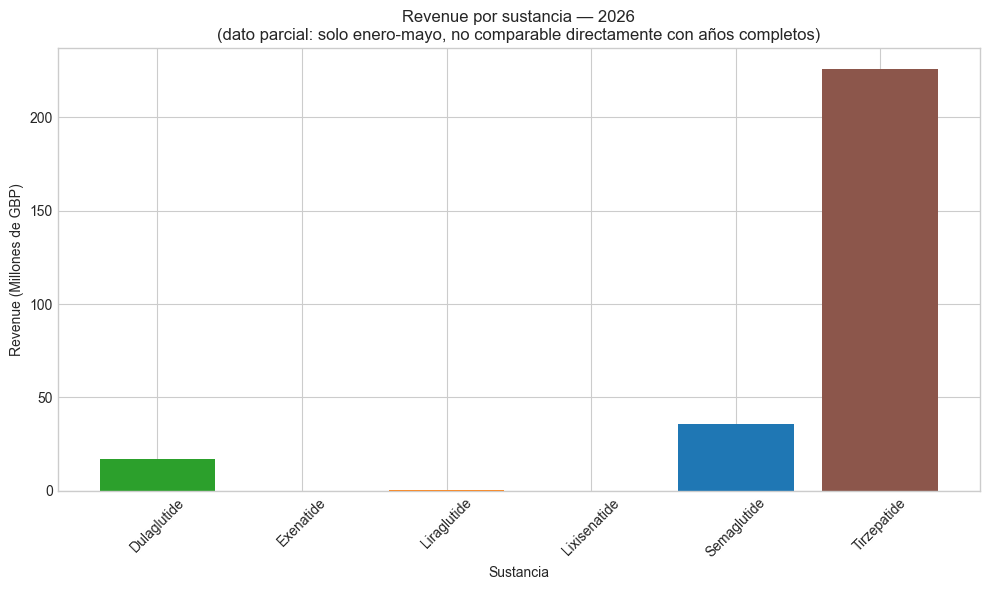

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

datos_2026 = revenue_anio_sustancia.loc[2026] / 1_000_000
colores_2026 = [color_sustancia[s] for s in datos_2026.index]

ax.bar(datos_2026.index, datos_2026.values, color=colores_2026)

ax.set_xlabel('Sustancia')
ax.set_ylabel('Revenue (Millones de GBP)')
ax.set_title('Revenue por sustancia — 2026\n(dato parcial: solo enero-mayo, no comparable directamente con años completos)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##Tirzepatide genera el mayor revenue total (£572M) de las 6 sustancias, a pesar de tener menos recetas (3.4M) que Semaglutide (4.96M, £433M) y Dulaglutide (4.89M, £381M)

C:\Users\esmeg\AppData\Local\Temp\ipykernel_9972\2650210598.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  cajas = ax.boxplot(datos_por_region, labels=regiones_ordenadas, showfliers=False, patch_artist=True)


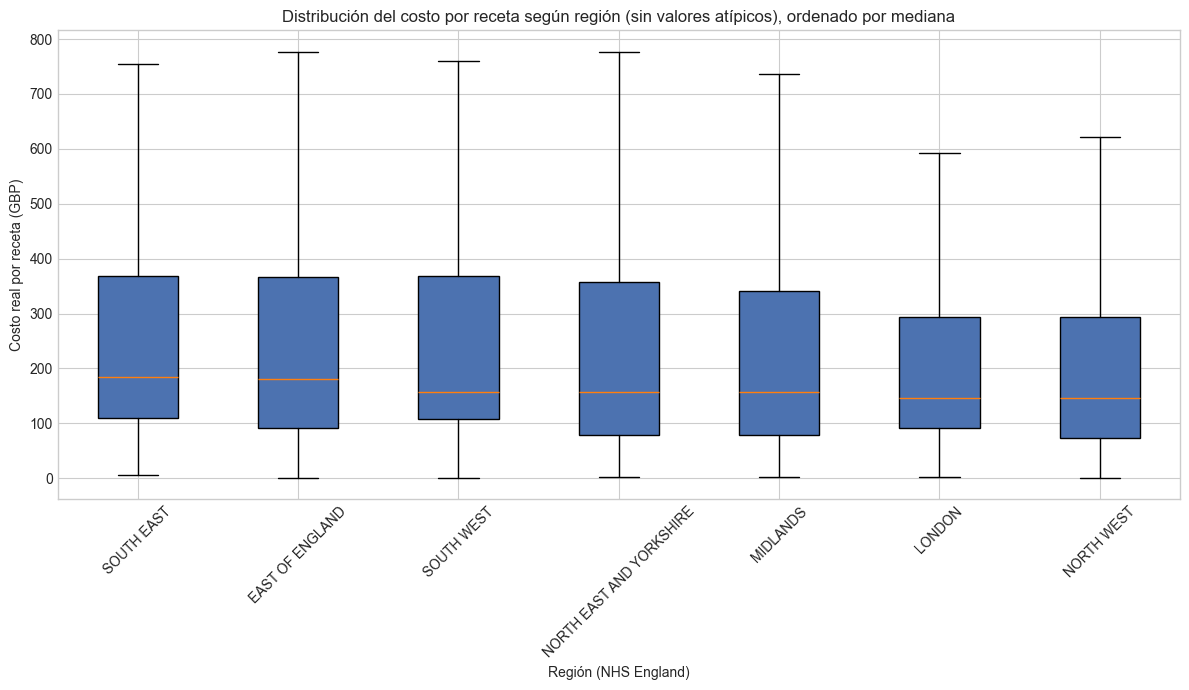

In [31]:
#box plot para comparar la distribución de costo por región

medianas = df_final.groupby('REGIONAL_OFFICE_NAME')['ACTUAL_COST'].median().sort_values(ascending=False)
regiones_ordenadas = medianas.index

datos_por_region = [df_final[df_final['REGIONAL_OFFICE_NAME'] == r]['ACTUAL_COST'] for r in regiones_ordenadas]

fig, ax = plt.subplots(figsize=(12, 7))
cajas = ax.boxplot(datos_por_region, labels=regiones_ordenadas, showfliers=False, patch_artist=True)

for caja in cajas['boxes']:
    caja.set_facecolor('#4C72B0')

ax.set_xlabel('Región (NHS England)')
ax.set_ylabel('Costo real por receta (GBP)')
ax.set_title('Distribución del costo por receta según región (sin valores atípicos), ordenado por mediana')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##Las 7 regiones tienen precios "típicos" (medianas) bastante parecidos entre sí (£145-185), así que ninguna destaca por tener recetas más caras en general. Donde sí hay diferencias claras es en la variabilidad

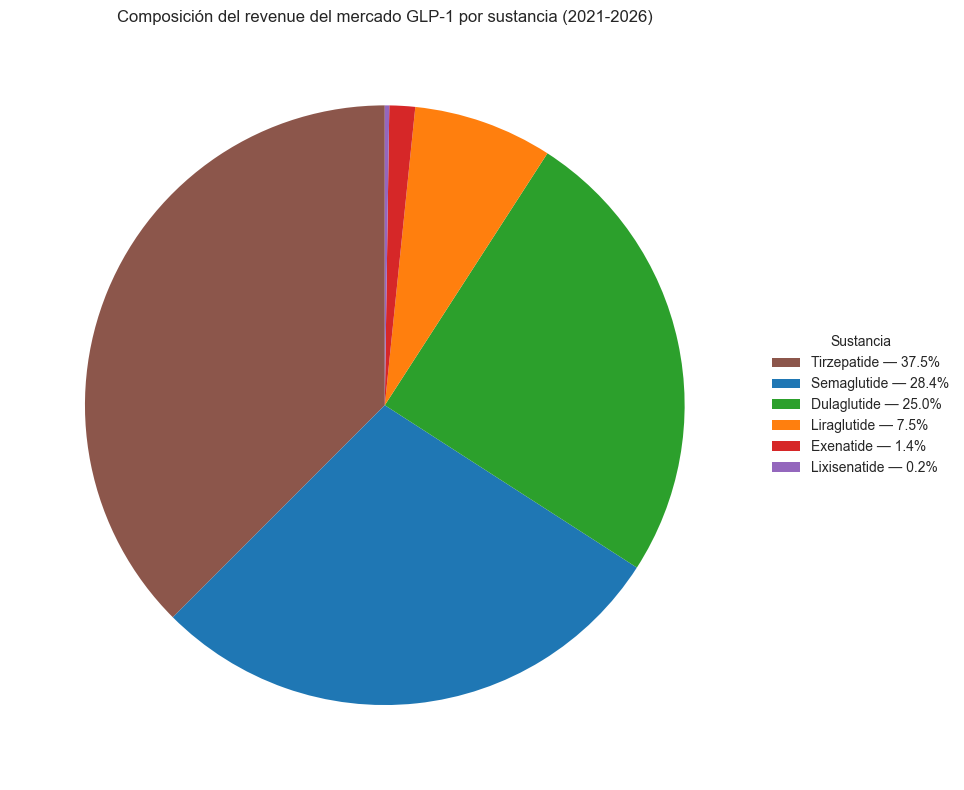

In [37]:
##Gráfica de pastel para mostrar la composición del mercado GLP-1 por sustancia (% del revenue total)
fig, ax = plt.subplots(figsize=(10, 8))
colores_pastel = [color_sustancia[s] for s in revenue_por_sustancia.index]

porcentajes = revenue_por_sustancia / revenue_por_sustancia.sum() * 100
etiquetas_leyenda = [f'{s} — {p:.1f}%' for s, p in zip(revenue_por_sustancia.index, porcentajes)]

wedges, texts = ax.pie(
    revenue_por_sustancia.values,
    colors=colores_pastel,
    startangle=90
)

ax.legend(wedges, etiquetas_leyenda, title='Sustancia', 
          loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_title('Composición del revenue del mercado GLP-1 por sustancia (2021-2026)')

plt.tight_layout()
plt.show()

In [38]:
df_final['ANIO'] = df_final['FECHA'].dt.year
revenue_anio_sustancia = df_final.groupby(['ANIO', 'SUSTANCIA'])['ACTUAL_COST'].sum().unstack()
print(revenue_anio_sustancia)

SUSTANCIA   Dulaglutide     Exenatide   Liraglutide  Lixisenatide  \
ANIO                                                                
2021       6.420144e+07  5.990440e+06  4.214402e+07  1.639334e+06   
2022       8.705876e+07  4.560848e+06  3.651701e+07  1.152892e+06   
2023       9.592470e+07  4.859529e+06  3.077575e+07  7.747766e+05   
2024       6.924250e+07  3.951752e+06  3.301402e+06  8.219363e+04   
2025       4.787456e+07  1.715216e+06  1.192079e+06  3.766157e+03   
2026       1.697138e+07  4.275700e+04  5.316407e+05           NaN   

SUSTANCIA   Semaglutide   Tirzepatide  
ANIO                                   
2021       5.367031e+07           NaN  
2022       8.673493e+07           NaN  
2023       7.283622e+07  1.366947e+03  
2024       9.255914e+07  7.006844e+07  
2025       9.134970e+07  2.765906e+08  
2026       3.606341e+07  2.257085e+08  


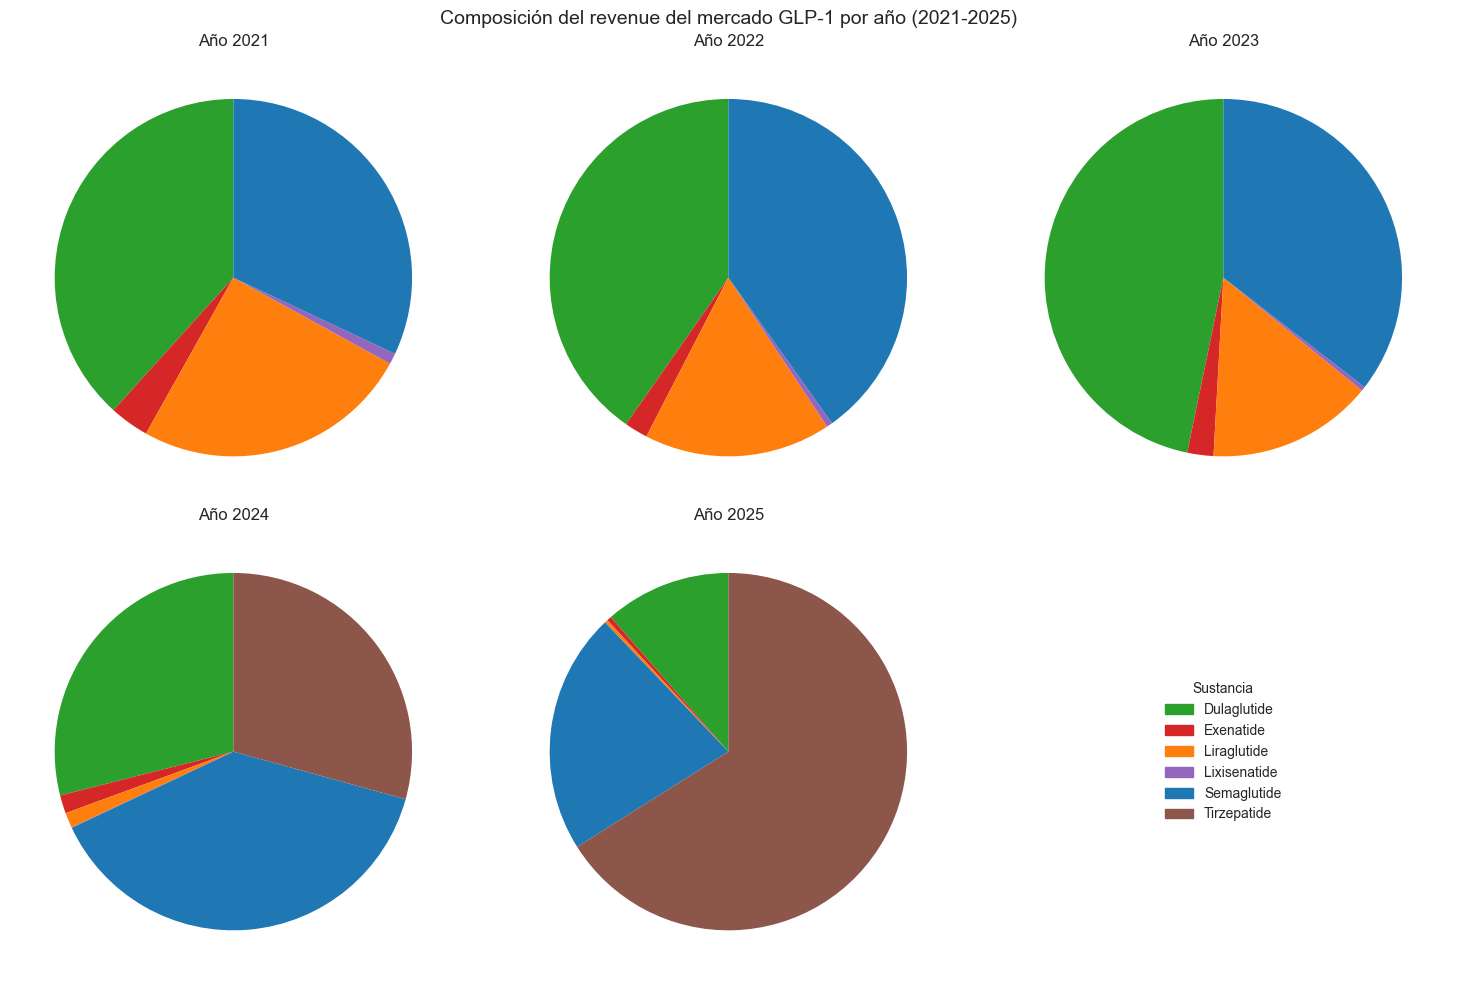

In [41]:
revenue_anio_sustancia = revenue_anio_sustancia.fillna(0)
anios_completos = [2021, 2022, 2023, 2024, 2025]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, anio in enumerate(anios_completos):
    datos_anio = revenue_anio_sustancia.loc[anio]
    colores = [color_sustancia[s] for s in datos_anio.index]
    axes[i].pie(datos_anio.values, colors=colores, startangle=90)
    axes[i].set_title(f'Año {anio}')

axes[5].axis('off')
handles = [plt.Rectangle((0,0),1,1, color=color_sustancia[s]) for s in revenue_anio_sustancia.columns]
axes[5].legend(handles, revenue_anio_sustancia.columns, loc='center', title='Sustancia')

fig.suptitle('Composición del revenue del mercado GLP-1 por año (2021-2025)', fontsize=14)
plt.tight_layout()
plt.show()

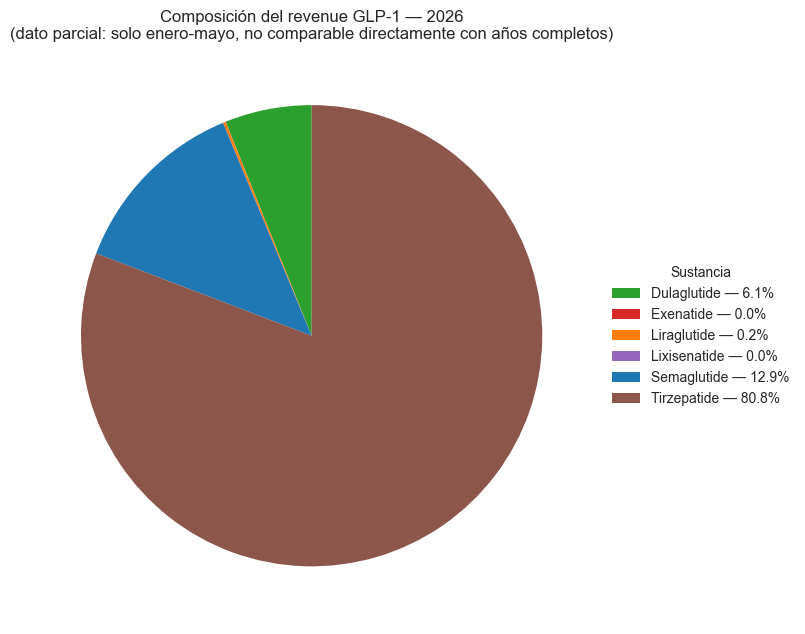

In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

datos_2026 = revenue_anio_sustancia.loc[2026]
colores_2026 = [color_sustancia[s] for s in datos_2026.index]

porcentajes_2026 = datos_2026 / datos_2026.sum() * 100
etiquetas_2026 = [f'{s} — {p:.1f}%' for s, p in zip(datos_2026.index, porcentajes_2026)]

wedges, texts = ax.pie(datos_2026.values, colors=colores_2026, startangle=90)

ax.legend(wedges, etiquetas_2026, title='Sustancia', 
          loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_title('Composición del revenue GLP-1 — 2026\n(dato parcial: solo enero-mayo, no comparable directamente con años completos)')

plt.tight_layout()
plt.show()

In [59]:
##Grafica de dispersion para ver el Patrón volumen-vs-precio repetido en regiones

resumen_anio_sustancia = df_final[df_final['ANIO'] != 2026].groupby(['ANIO', 'SUSTANCIA'])[['ACTUAL_COST', 'TOTAL_QUANTITY']].sum().reset_index()
print(resumen_anio_sustancia.head())

resumen_anio_sustancia.shape

   ANIO     SUSTANCIA   ACTUAL_COST  TOTAL_QUANTITY
0  2021   Dulaglutide  6.420144e+07         3760773
1  2021     Exenatide  5.990440e+06          229608
2  2021   Liraglutide  4.214402e+07         1152068
3  2021  Lixisenatide  1.639334e+06           60480
4  2021   Semaglutide  5.367031e+07         1984102


(28, 4)

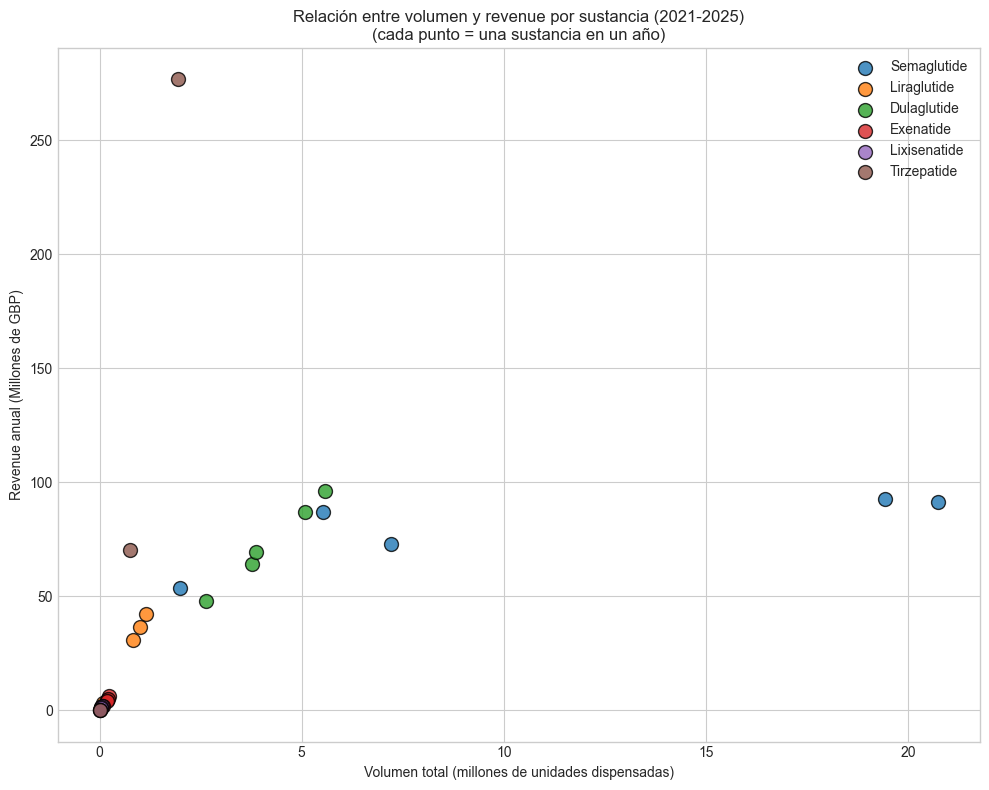

In [63]:
fig, ax = plt.subplots(figsize=(10, 8))

for sustancia in sustancias_lista:
    datos_sustancia = resumen_anio_sustancia[resumen_anio_sustancia['SUSTANCIA'] == sustancia]
    ax.scatter(datos_sustancia['TOTAL_QUANTITY'] / 1_000_000, datos_sustancia['ACTUAL_COST'] / 1_000_000,
               color=color_sustancia[sustancia], label=sustancia, s=100, alpha=0.8, edgecolors='black')

ax.set_xlabel('Volumen total (millones de unidades dispensadas)')
ax.set_ylabel('Revenue anual (Millones de GBP)')
ax.set_title('Relación entre volumen y revenue por sustancia (2021-2025)\n(cada punto = una sustancia en un año)')
ax.legend()

plt.tight_layout()
plt.show()